# ¿El núcleo interno de la Tierra alarga y acorta el día?

**3,1 milisegundos.** Eso es lo que cambió la duración del día, en su componente lenta (la que se mueve
a lo largo de décadas), entre 1973 y 2019. Casi nada de eso vino de fuera de la Tierra: algo en su interior
intercambia giro con el manto.

¿Quién está tirando?

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Zhang y Dumberry (2026), *Nature* — «Gravitational torque drives multidecadal variations in length of day»
**DOI:** [10.1038/s41586-026-10999-2](https://doi.org/10.1038/s41586-026-10999-2)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-09-23-torque-gravitacional-duracion-dia/notebook.ipynb)

**Video:** [Ver en YouTube](https://youtube.com/shorts/wQagnAK7fWk)

## El día no dura siempre lo mismo

La duración del día (LOD, *length of day*) sube y baja unos milisegundos de una década a otra. Si el manto
gira más rápido, el día se acorta; si gira más lento, se alarga. Ese giro se lo intercambia con el núcleo, y
hay tres candidatos para hacer el intercambio, tres torques (fuerzas que hacen girar): un **torque electromagnético** y uno **topográfico** (por el relieve) en el borde
entre el núcleo y el manto (la frontera núcleo-manto, a 2.900 km de profundidad), y un **torque gravitacional**
del núcleo interno sólido, que gira un poco a destiempo del manto y se desalinea con él.

El equipo de Zhang y Dumberry (Universidad de Alberta) combinó la rotación del núcleo interno reconstruida con
ondas sísmicas y los flujos del núcleo deducidos del campo magnético, y comparó qué torque encaja mejor con el
día medido. Aquí usamos sus datos públicos (Borealis) para verlo nosotros.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
GAMMA_NM = 1.3e19      # amplitud del torque gravitacional (N m) usada en la Fig. 1 del paper
K_EM = 1.0             # acoplamiento electromagnético: conductancia del manto en unidades de 10^8 S
K_TOP = 0.4            # escala del torque topográfico (Fig. 1 del paper)
PROB_MIN = 0.6         # umbral de "alta probabilidad" de las muestras del MCMC (el del código de los autores)
# La desalineación α del núcleo interno viene calculada para τ = 6 años (tiempo de relajación
# viscosa del núcleo interno); por eso aquí τ no es un parámetro libre.
FUENTE = 'Fuente: Zhang y Dumberry (2026), Nature | Datos: Borealis doi:10.5683/SP3/RA3KHX'
COLOR_DATOS = '#2563EB'
COLOR_ALERTA = '#DC2626'
COLOR_REFERENCIA = '#D97706'
COLOR_EM = '#7C3AED'
COLOR_TOP = '#059669'
COLOR_GRIS = '#BBBBBB'

import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import gaussian_kde
import re


def es(x):
    # Números en formato español para los prints: 1.35e+19 → 1,35×10^19; 20_089 → 20.089
    x = re.sub(r'(?<=\d)\.(?=\d)', ',', str(x))
    x = re.sub(r'(\d)e\+?(-?)0*(\d+)', r'\1×10^\2\3', x)
    return x.replace('_', '.')


def pr(*args):
    print(*(es(a) for a in args))

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)
os.makedirs('figuras', exist_ok=True)

os.makedirs('datos', exist_ok=True)
ARCHIVOS = ['dlod_1964_2019.csv', 'torques_cmb_ensemble.csv', 'alpha_nucleo_interno_tau6.csv',
            'posterior_em.csv', 'posterior_top.csv']
for f in ARCHIVOS:
    if not os.path.exists(f'datos/{f}'):
        urllib.request.urlretrieve(f'{BASE}/papers/2026-09-23-torque-gravitacional-duracion-dia/datos/{f}', f'datos/{f}')

lod = pd.read_csv('datos/dlod_1964_2019.csv')           # ΔLOD diario (ms): decadal y filtrado >30 años
cmb = pd.read_csv('datos/torques_cmb_ensemble.csv')     # torques EM y topográfico de referencia (anual)
alf = pd.read_csv('datos/alpha_nucleo_interno_tau6.csv')  # desalineación α del núcleo interno (grados)
post_em = pd.read_csv('datos/posterior_em.csv')         # muestras del MCMC con prob > 0,3
post_top = pd.read_csv('datos/posterior_top.csv')

# ── Constantes (fig1.py de los autores) ──────────────────────
CM = 7.13e37                  # momento de inercia axial del manto (kg m²)
DIA = 86400.0
ANIO = 365.25 * DIA
OMEGA = 2 * np.pi / DIA


def lod_desde_torque(t, torque):
    # Integra el torque (N m) en el tiempo (años) → cambio de rotación del manto → ΔLOD (ms)
    domega = ANIO / CM * torque
    omega = np.concatenate([[0], np.cumsum((domega[:-1] + domega[1:]) / 2 * np.diff(t))])
    dlod = -2 * np.pi / OMEGA**2 * omega * 1000
    return dlod - dlod.mean()


def torque_desde_lod(t, dlod_ms):
    # Ec. 3 del paper: torque que haría falta para producir ese ΔLOD
    omega = -2 * np.pi * (dlod_ms / 1000) / DIA**2
    return CM / ANIO * np.gradient(omega, t)


# ΔLOD observado (restamos la media de la ventana, como fig1.py)
t_obs = lod['anio'].values
lod_dec = lod['dlod_decadal_ms'].values - lod['dlod_decadal_ms'].mean()
lod_multi = lod['dlod_multidecadal_ms'].values - lod['dlod_multidecadal_ms'].mean()

# Torques predichos
t_cmb = cmb['anio'].values
torque_em = 0.33 * K_EM * (cmb['torque_em_ref_3e8S_Nm'] - cmb['torque_em_ref_3e8S_Nm'].mean()).values
torque_top = K_TOP * (cmb['torque_top_ref_Ktop1_Nm'] - cmb['torque_top_ref_Ktop1_Nm'].mean()).values
t_grav = alf['anio'].values
torque_grav = GAMMA_NM * np.deg2rad(alf['alpha_grados'].values)

lod_em = lod_desde_torque(t_cmb, torque_em)
lod_top = lod_desde_torque(t_cmb, torque_top)
lod_grav = lod_desde_torque(t_grav, torque_grav)

# Torque requerido por el ΔLOD observado
# (cada 10 días: los ΔLOD vienen redondeados a 6 cifras y la derivada día a día amplifica ese ruido)
t_req = t_obs[::10]
torque_req_dec = torque_desde_lod(t_req, lod_dec[::10])
torque_req_multi = torque_desde_lod(t_req, lod_multi[::10])

pr(f'ΔLOD diario: {len(lod):_} días, {t_obs.min():.1f}–{t_obs.max():.1f}')
pr(f'ΔLOD multidecadal: máx {lod_multi.max():+.2f} ms ({t_obs[lod_multi.argmax()]:.1f}), '
      f'mín {lod_multi.min():+.2f} ms ({t_obs[lod_multi.argmin()]:.1f}), '
      f'pico a pico {np.ptp(lod_multi):.2f} ms')
pr(f'ΔLOD decadal: pico a pico {np.ptp(lod_dec):.2f} ms')
pr(f'Torques EM/TOP: {len(cmb)} años | α del núcleo interno: {len(alf)} puntos semestrales')
pr(f'Muestras MCMC guardadas (prob > 0,3): EM {len(post_em):_} | TOP {len(post_top):_}')

ΔLOD diario: 20.089 días, 1964,0–2019,0
ΔLOD multidecadal: máx +1,38 ms (1973,0), mín -1,71 ms (2019,0), pico a pico 3,09 ms
ΔLOD decadal: pico a pico 3,74 ms
Torques EM/TOP: 56 años | α del núcleo interno: 111 puntos semestrales
Muestras MCMC guardadas (prob > 0,3): EM 25.094 | TOP 28.058


## Aquí está.

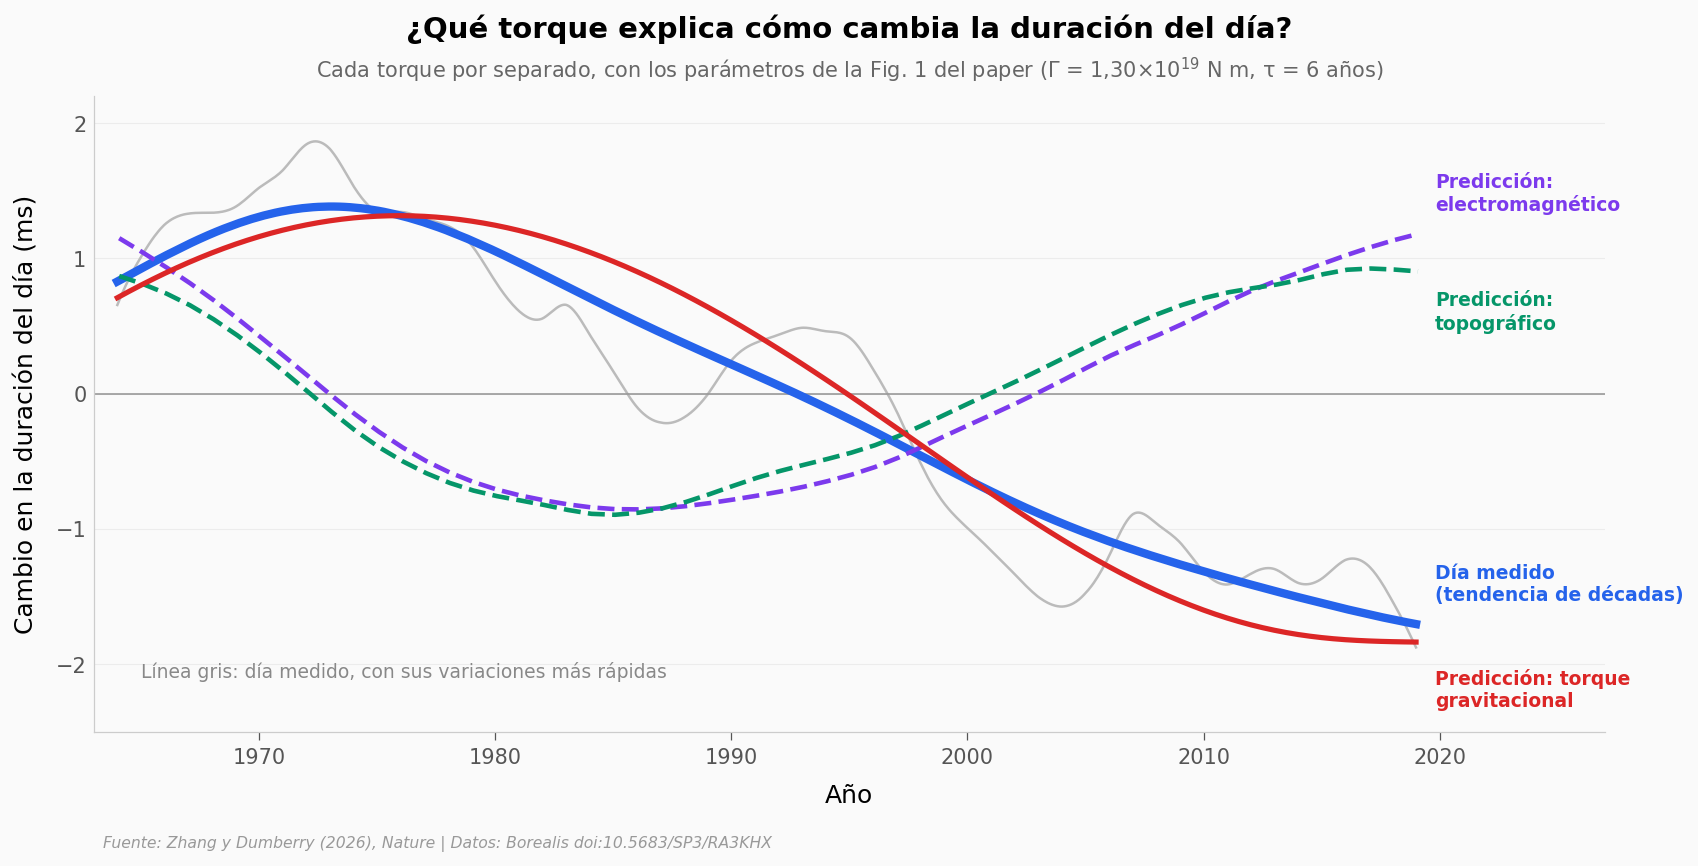

Torque                 r       ρ  RMS (ms)
Gravitacional      0,986   0,979     0,215
Electromagnético  -0,433  -0,390     1,492
Topográfico       -0,553  -0,524     1,509
RMS de predecir "cero cambio": 1,058 ms (malla semestral), 1,062 ms (malla anual)


In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(t_obs, lod_dec, color=COLOR_GRIS, lw=1.2, zorder=2)
ax.plot(t_obs, lod_multi, color=COLOR_DATOS, lw=4, zorder=3)
ax.plot(t_cmb, lod_em, color=COLOR_EM, lw=2.2, ls='--', zorder=4)
ax.plot(t_cmb, lod_top, color=COLOR_TOP, lw=2.2, ls='--', zorder=4)
ax.plot(t_grav, lod_grav, color=COLOR_ALERTA, lw=2.5, zorder=5)
ax.axhline(0, color='#999999', lw=0.8)

x_lab = 2019.8
ax.text(x_lab, lod_multi[-1] + 0.3, 'Día medido\n(tendencia de décadas)', color=COLOR_DATOS, fontsize=9, fontweight='bold', va='center')
ax.text(x_lab, lod_grav[-1] - 0.35, 'Predicción: torque\ngravitacional', color=COLOR_ALERTA, fontsize=9, fontweight='bold', va='center')
ax.text(x_lab, lod_em[-1] + 0.3, 'Predicción:\nelectromagnético', color=COLOR_EM, fontsize=9, fontweight='bold', va='center')
ax.text(x_lab, lod_top[-1] - 0.3, 'Predicción:\ntopográfico', color=COLOR_TOP, fontsize=9, fontweight='bold', va='center')
ax.text(1965, -2.1, 'Línea gris: día medido, con sus variaciones más rápidas', color='#888888', fontsize=9)
ax.set_xlim(1963, 2027)
ax.set_ylim(-2.5, 2.2)
ax.set_xlabel('Año')
ax.set_ylabel('Cambio en la duración del día (ms)')
ax.set_title('¿Qué torque explica cómo cambia la duración del día?', fontsize=14, fontweight='bold', pad=28)
gamma_txt = f'{GAMMA_NM / 1e19:.2f}'.replace('.', ',')
ax.text(0.5, 1.03, f'Cada torque por separado, con los parámetros de la Fig. 1 del paper (Γ = {gamma_txt}×10$^{{19}}$ N m, τ = 6 años)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/duracion_dia_predicciones.png', dpi=200, bbox_inches='tight')
plt.show()

# ¿Qué tanto se parece cada predicción a lo medido? (sobre la malla de cada predicción)
obs_grav = np.interp(t_grav, t_obs, lod_multi)
obs_cmb = np.interp(t_cmb, t_obs, lod_multi)
pr(f'{"Torque":<16}{"r":>8}{"ρ":>8}{"RMS (ms)":>10}')
for nombre, pred, obs in [('Gravitacional', lod_grav, obs_grav), ('Electromagnético', lod_em, obs_cmb),
                          ('Topográfico', lod_top, obs_cmb)]:
    r = np.corrcoef(pred, obs)[0, 1]
    rho = stats.spearmanr(pred, obs)[0]
    rms = np.sqrt(np.mean((pred - obs)**2))
    pr(f'{nombre:<16}{r:>8.3f}{rho:>8.3f}{rms:>10.3f}')
pr(f'RMS de predecir "cero cambio": {np.sqrt(np.mean(obs_grav**2)):.3f} ms (malla semestral), '
      f'{np.sqrt(np.mean(obs_cmb**2)):.3f} ms (malla anual)')

Lo que salta a la vista: el torque gravitacional, él solo, calca la tendencia lenta del día. Correlación r = 0,986 (111 puntos semestrales, pero cada uno se parece mucho al anterior)
y un error típico (RMS) de 0,215 ms, cuando la señal misma se aleja de cero en promedio 1,06 ms.

Los dos torques del borde núcleo-manto hacen lo contrario: van en sentido opuesto al día medido (r = −0,43 el
electromagnético, r = −0,55 el topográfico; 56 puntos anuales) y fallan más que si predijéramos «no cambia nada» (RMS de 1,49 y
1,51 ms). No es un espejo exacto, pero el signo está al revés. Encaja con lo que sugiere el paper: serían torques que
**frenan** el cambio, no que lo producen.

Dos advertencias. Esta es UNA combinación de parámetros, la que los autores eligieron para su Fig. 1; los rangos
vienen más abajo. Y las curvas son suaves y cubren menos de un ciclo de la oscilación de unos 70 años que
describe el paper: por eso no damos p-values, solo describimos cuánto se parecen las formas.

## El mismo cambio, visto como fuerza

Si el día cambia, algo tuvo que aplicar un torque sobre el manto. La ecuación 3 del paper traduce el ΔLOD medido
en el torque que haría falta. Veamos cuándo llega ese torque a su máximo y cuándo lo hace el gravitacional.

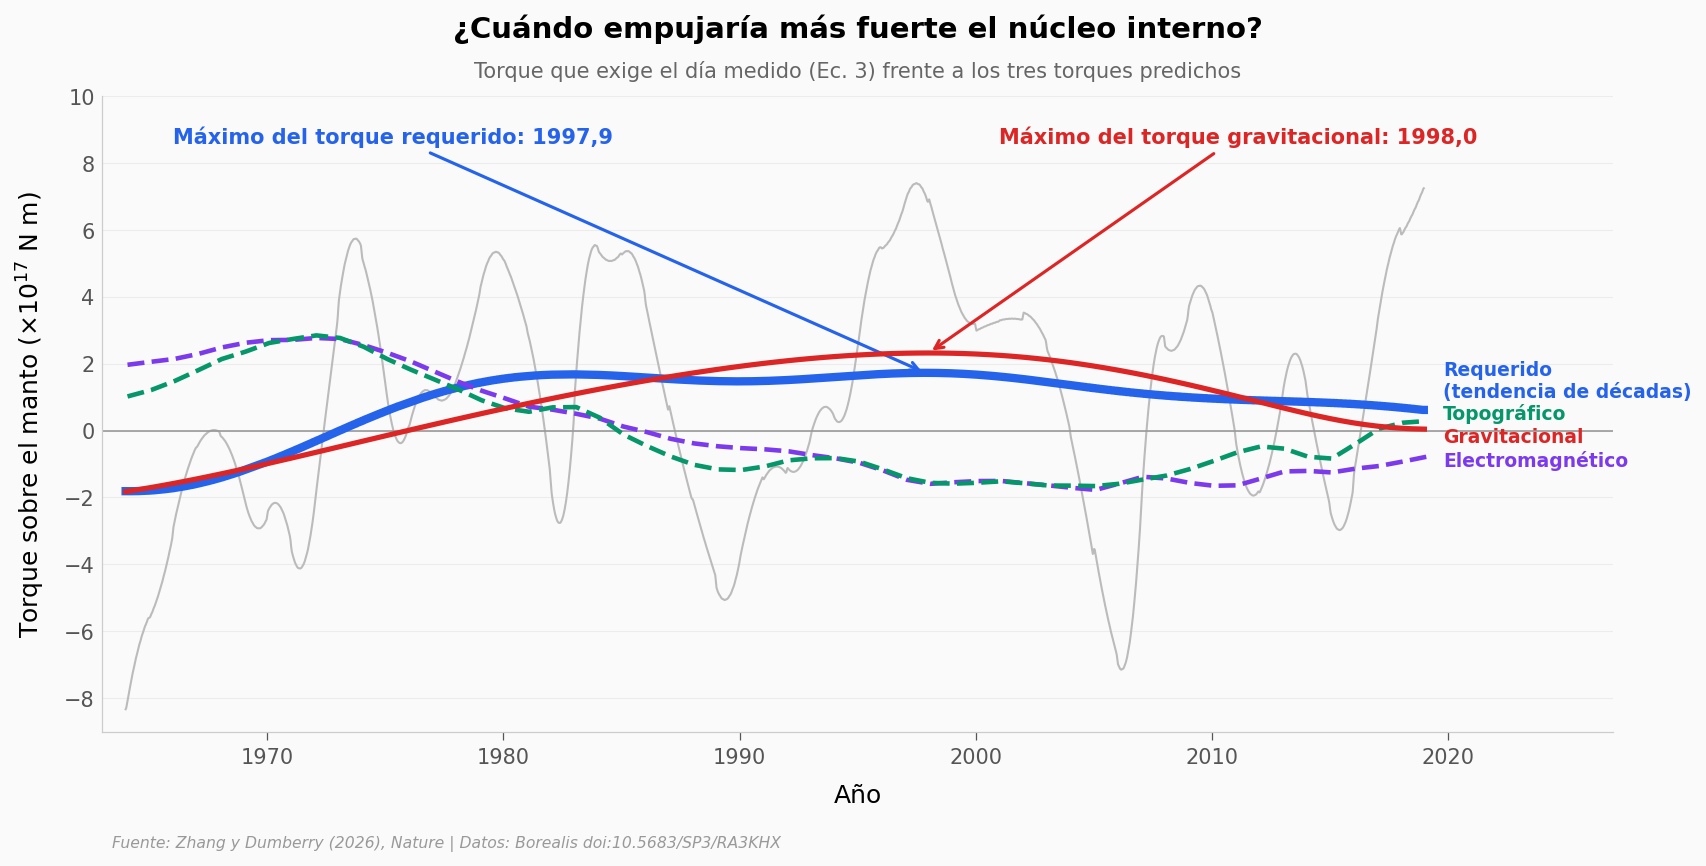

Torque requerido (tendencia de décadas): de -1,81 (1964,2) a +1,73 ×10^17 N m (1997,9)
Torque requerido (decadal, ruidoso): P5–P95 = -5,04 a +5,98 ×10^17 N m
Desalineación α del núcleo interno: máx +1,02° (1998,0), mín -0,80° (1964,0)


In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(t_req, torque_req_dec / 1e17, color=COLOR_GRIS, lw=1, zorder=2)
ax.plot(t_req, torque_req_multi / 1e17, color=COLOR_DATOS, lw=4, zorder=3)
ax.plot(t_cmb, torque_em / 1e17, color=COLOR_EM, lw=2.2, ls='--', zorder=4)
ax.plot(t_cmb, torque_top / 1e17, color=COLOR_TOP, lw=2.2, ls='--', zorder=4)
ax.plot(t_grav, torque_grav / 1e17, color=COLOR_ALERTA, lw=2.5, zorder=5)
ax.axhline(0, color='#999999', lw=0.8)

i_req = torque_req_multi.argmax()
i_grav = torque_grav.argmax()
ax.annotate(f'Máximo del torque requerido: {t_req[i_req]:.1f}'.replace('.', ','),
            xy=(t_req[i_req], torque_req_multi[i_req] / 1e17), xytext=(1966, 8.6),
            fontsize=10, fontweight='bold', color=COLOR_DATOS,
            arrowprops=dict(arrowstyle='->', color=COLOR_DATOS, lw=1.5))
ax.annotate(f'Máximo del torque gravitacional: {t_grav[i_grav]:.1f}'.replace('.', ','),
            xy=(t_grav[i_grav], torque_grav[i_grav] / 1e17), xytext=(2001, 8.6),
            fontsize=10, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))
ax.text(2019.8, -0.2, 'Gravitacional', color=COLOR_ALERTA, fontsize=9, fontweight='bold', va='center')
ax.text(2019.8, -0.9, 'Electromagnético', color=COLOR_EM, fontsize=9, fontweight='bold', va='center')
ax.text(2019.8, 0.5, 'Topográfico', color=COLOR_TOP, fontsize=9, fontweight='bold', va='center')
ax.text(2019.8, 1.5, 'Requerido\n(tendencia de décadas)', color=COLOR_DATOS, fontsize=9, fontweight='bold', va='center')
ax.set_xlim(1963, 2027)
ax.set_ylim(-9, 10)
ax.set_yticks(range(-8, 11, 2))
ax.set_xlabel('Año')
ax.set_ylabel('Torque sobre el manto (×10$^{17}$ N m)')
ax.set_title('¿Cuándo empujaría más fuerte el núcleo interno?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Torque que exige el día medido (Ec. 3) frente a los tres torques predichos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/torque_requerido.png', dpi=200, bbox_inches='tight')
plt.show()

pr(f'Torque requerido (tendencia de décadas): de {torque_req_multi.min()/1e17:+.2f} ({t_req[torque_req_multi.argmin()]:.1f}) '
      f'a {torque_req_multi.max()/1e17:+.2f} ×10^17 N m ({t_req[i_req]:.1f})')
p5, p95 = np.percentile(torque_req_dec, [5, 95]) / 1e17
pr(f'Torque requerido (decadal, ruidoso): P5–P95 = {p5:+.2f} a {p95:+.2f} ×10^17 N m')
pr(f'Desalineación α del núcleo interno: máx {alf.alpha_grados.max():+.2f}° ({t_grav[alf.alpha_grados.argmax()]:.1f}), '
      f'mín {alf.alpha_grados.min():+.2f}° ({t_grav[alf.alpha_grados.argmin()]:.1f})')

El torque que exige la tendencia lenta del día va de −1,81×10¹⁷ N m a inicios de 1964 a +1,73×10¹⁷ N m en 1997,9.
El gravitacional llega a su máximo en 1998,0, casi a la vez, cuando la desalineación del núcleo interno es mayor (+1,02°). El paper
lo resume así: el máximo cae «alrededor del año 2000». La curva gris, la de las variaciones más rápidas, es mucho más
ruidosa (entre −5,04 y +5,98 ×10¹⁷ N m el 90 % del tiempo); esa parte no la explica el torque gravitacional, y el
paper apunta a que probablemente la manejan los torques del borde núcleo-manto.

## ¿Y si los parámetros fueran otros?

La Fig. 1 es una sola elección. Para ver qué rango de valores es compatible con el día medido, los autores corrieron
una inversión bayesiana (un MCMC, un método que prueba combinaciones al azar y se queda más tiempo en las que mejor encajan; aquí, 5 cadenas × 18.000 muestras = 90.000 combinaciones por tipo de acoplamiento) sobre
tres parámetros: la fuerza del torque gravitacional (Γ), el tiempo que tarda el núcleo interno en deformarse (τ) y la
fuerza del torque en el borde núcleo-manto (K). Aquí cargamos las muestras con probabilidad > 0,3 y nos quedamos con
las de alta probabilidad.

Muestras de alta probabilidad (prob > 0,6): EM 4.820 | TOP 6.329


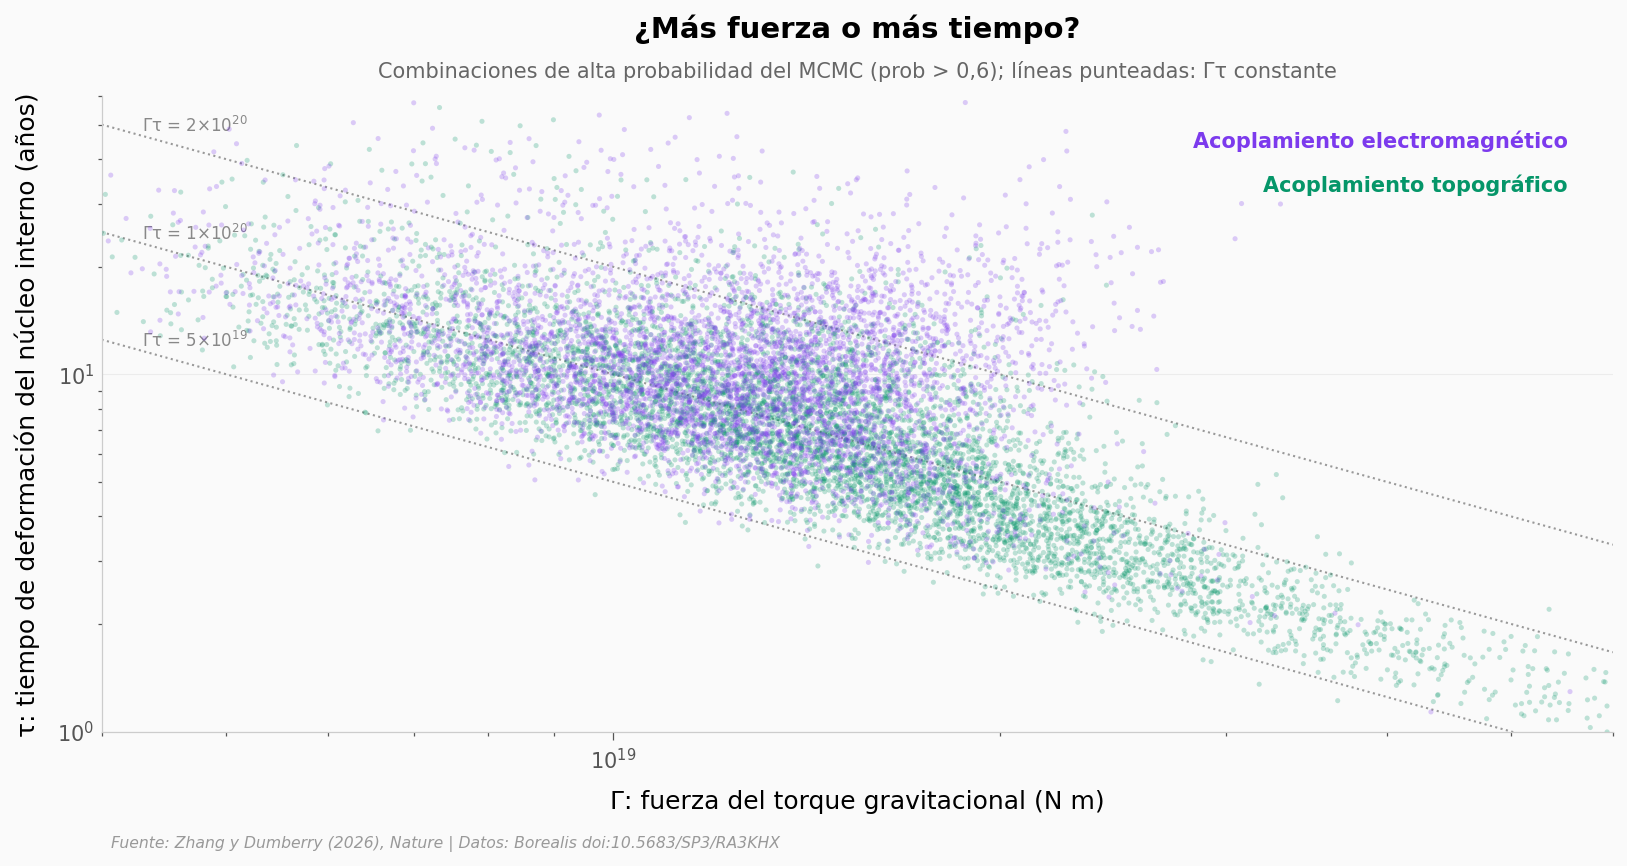

EM: ρ(Γ, τ) = -0,31 | Γτ mediana = 1,19×10^20 N m año | IC 95 % = 6,18×10^19 a 4,00×10^20
TOP: ρ(Γ, τ) = -0,81 | Γτ mediana = 9,13×10^19 N m año | IC 95 % = 5,63×10^19 a 2,25×10^20
Cociente de medianas Γτ (EM / TOP): 1,30


In [4]:
em = post_em[post_em['prob'] > PROB_MIN]
top = post_top[post_top['prob'] > PROB_MIN]
pr(f'Muestras de alta probabilidad (prob > {PROB_MIN}): EM {len(em):_} | TOP {len(top):_}')

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.scatter(em['gamma_Nm'], em['tau_anios'], s=6, alpha=0.25, color=COLOR_EM, edgecolors='none', zorder=4)
ax.scatter(top['gamma_Nm'], top['tau_anios'], s=6, alpha=0.25, color=COLOR_TOP, edgecolors='none', zorder=3)
g = np.logspace(np.log10(4e18), np.log10(6e19), 50)
for prod in [5e19, 1e20, 2e20]:
    ax.plot(g, prod / g, color='#999999', lw=1, ls=':', zorder=2)
    ax.text(4.3e18, prod / 4.3e18, f'Γτ = {prod:.0e}'.replace('e+', '×10^').replace('×10^19', '×10$^{19}$').replace('×10^20', '×10$^{20}$'),
            fontsize=8, color='#888888', va='bottom')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(4e18, 6e19)
ax.set_ylim(1, 60)
ax.set_xlabel('Γ: fuerza del torque gravitacional (N m)')
ax.set_ylabel('τ: tiempo de deformación del núcleo interno (años)')
ax.text(0.97, 0.92, 'Acoplamiento electromagnético', transform=ax.transAxes, color=COLOR_EM, fontsize=10, fontweight='bold', ha='right')
ax.text(0.97, 0.85, 'Acoplamiento topográfico', transform=ax.transAxes, color=COLOR_TOP, fontsize=10, fontweight='bold', ha='right')
ax.set_title('¿Más fuerza o más tiempo?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Combinaciones de alta probabilidad del MCMC (prob > {PROB_MIN}); líneas punteadas: Γτ constante'.replace('.', ','),
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/gamma_tau_compromiso.png', dpi=200, bbox_inches='tight')
plt.show()

for nombre, d in [('EM', em), ('TOP', top)]:
    rho = stats.spearmanr(d['gamma_Nm'], d['tau_anios'])[0]
    gt = d['gamma_Nm'] * d['tau_anios']
    lo, hi = np.percentile(gt, [2.5, 97.5])
    pr(f'{nombre}: ρ(Γ, τ) = {rho:.2f} | Γτ mediana = {gt.median():.2e} N m año | IC 95 % = {lo:.2e} a {hi:.2e}')
gt_em = (em['gamma_Nm'] * em['tau_anios']).median()
gt_top = (top['gamma_Nm'] * top['tau_anios']).median()
pr(f'Cociente de medianas Γτ (EM / TOP): {gt_em / gt_top:.2f}')

Las nubes se inclinan: un torque gravitacional más fuerte se compensa con un núcleo interno que se deforma más
rápido, y al revés. El compromiso es mucho más marcado con el acoplamiento topográfico (correlación de rangos ρ = −0,81) que con el
electromagnético (ρ = −0,31). El paper dice que el producto Γτ «se mantiene aproximadamente igual». Con estas muestras, entre los dos
acoplamientos las medianas de Γτ difieren un 30 %, poco frente a lo que se dispersa cada nube
(intervalo del 95 % de Γτ: 0,62 a 4,0 ×10²⁰ con el electromagnético, 0,56 a 2,25 ×10²⁰ con el topográfico). Del mismo orden.

## ¿Qué tan fuerte tiene que ser el torque gravitacional?

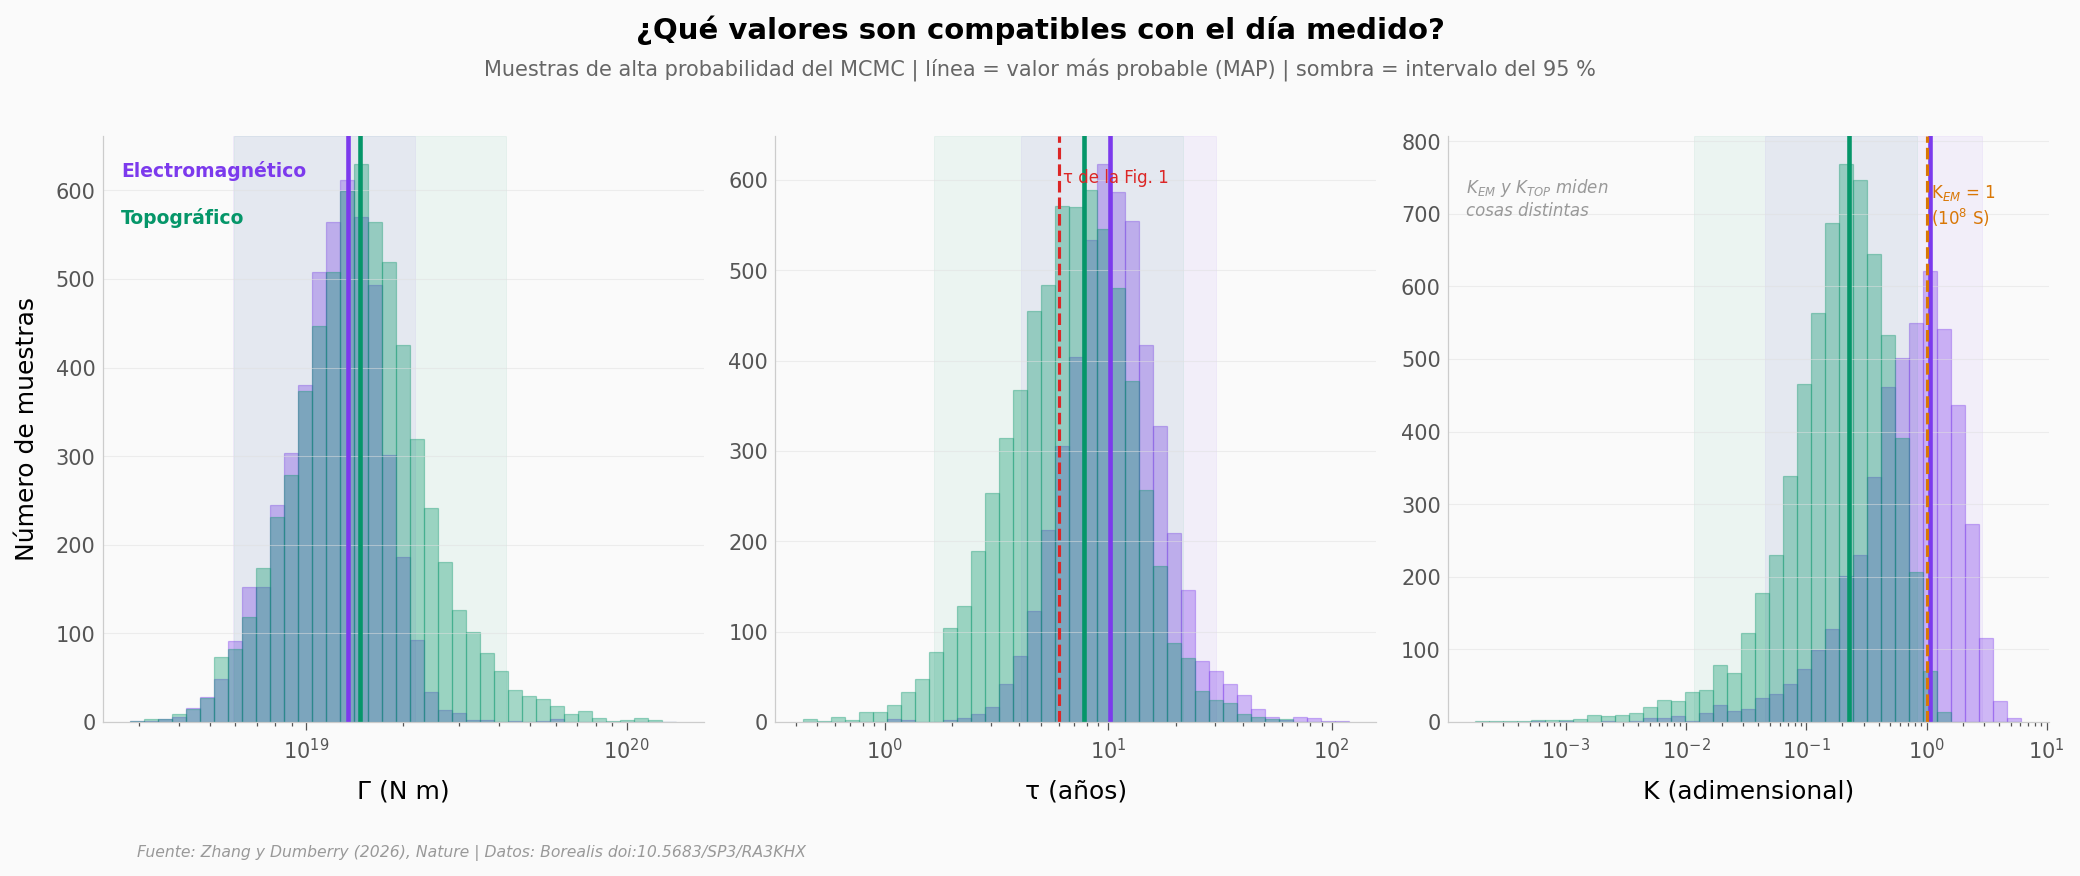

Acopl. Parámetro                   MAP     IC 2,5 %    IC 97,5 %      Mediana
EM     Γ (N m)              1,35×10^19   5,89×10^18   2,18×10^19   1,26×10^19
TOP    Γ (N m)              1,47×10^19   5,97×10^18    4,2×10^19   1,46×10^19
EM     τ (años)                   10,2         4,05         30,5         10,5
TOP    τ (años)                   7,78         1,66         21,5         6,82
EM     K (adimensional)           1,08       0,0456         2,89        0,785
TOP    K (adimensional)          0,228       0,0116         0,83        0,203


In [5]:
def kde_map(x):
    # Moda de la distribución estimada con un KDE en escala logarítmica (combine.py de los autores)
    z = np.log(np.asarray(x))
    grid = np.linspace(z.min(), z.max(), 4000)
    return float(np.exp(grid[np.argmax(gaussian_kde(z)(grid))]))

params = [('gamma_Nm', 'gamma_Nm', 'Γ (N m)'), ('tau_anios', 'tau_anios', 'τ (años)'), ('k_em', 'k_top', 'K (adimensional)')]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
resumen = []
for ax, (c_em, c_top, etiqueta) in zip(axes, params):
    lo = min(em[c_em].min(), top[c_top].min())
    hi = max(em[c_em].max(), top[c_top].max())
    bins = np.logspace(np.log10(lo), np.log10(hi), 40)
    for nombre, d, c, color in [('EM', em, c_em, COLOR_EM), ('TOP', top, c_top, COLOR_TOP)]:
        v = d[c].values
        n, _, _ = ax.hist(v, bins=bins, color=color, alpha=0.35, edgecolor=color, linewidth=0.6)
        mapa = kde_map(v)
        ic = np.percentile(v, [2.5, 97.5])
        ax.axvline(mapa, color=color, lw=2.2)
        ax.axvspan(ic[0], ic[1], color=color, alpha=0.06)
        resumen.append((nombre, etiqueta, mapa, ic[0], ic[1], np.median(v)))
    ax.set_xscale('log')
    ax.set_xlabel(etiqueta)
axes[0].set_ylabel('Número de muestras')
axes[0].text(0.03, 0.93, 'Electromagnético', transform=axes[0].transAxes, color=COLOR_EM, fontsize=9, fontweight='bold')
axes[0].text(0.03, 0.85, 'Topográfico', transform=axes[0].transAxes, color=COLOR_TOP, fontsize=9, fontweight='bold')
axes[1].axvline(6, color=COLOR_ALERTA, lw=1.5, ls='--')
axes[1].text(6.3, axes[1].get_ylim()[1] * 0.92, 'τ de la Fig. 1', color=COLOR_ALERTA, fontsize=8)
axes[2].axvline(K_EM, color=COLOR_REFERENCIA, lw=1.5, ls='--')
axes[2].text(K_EM * 1.08, axes[2].get_ylim()[1] * 0.92, 'K$_{EM}$ = 1\n(10$^8$ S)', color=COLOR_REFERENCIA, fontsize=8, va='top')
axes[2].text(0.03, 0.93, 'K$_{EM}$ y K$_{TOP}$ miden\ncosas distintas', transform=axes[2].transAxes, fontsize=8, color='#999999', ha='left', va='top', style='italic')
plt.tight_layout()
fig.suptitle('¿Qué valores son compatibles con el día medido?', fontsize=14, fontweight='bold', y=1.13)
fig.text(0.5, 1.045, f'Muestras de alta probabilidad del MCMC | línea = valor más probable (MAP) | sombra = intervalo del 95 %',
         fontsize=10, color='#666666', ha='center')
fig.text(0.07, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/posterior_parametros.png', dpi=200, bbox_inches='tight')
plt.show()

pr(f'{"Acopl.":<7}{"Parámetro":<18}{"MAP":>13}{"IC 2,5 %":>13}{"IC 97,5 %":>13}{"Mediana":>13}')
for nombre, etiqueta, mapa, a, b, med in resumen:
    pr(f'{nombre:<7}{etiqueta:<18}' + ''.join(f'{es(f"{v:.3g}"):>13}' for v in (mapa, a, b, med)))

Con acoplamiento electromagnético, el valor más probable de la fuerza del torque gravitacional es Γ = 1,35×10¹⁹ N m,
con un intervalo del 95 % de 0,59 a 2,18 ×10¹⁹; con el topográfico, 1,47×10¹⁹ (0,60 a 4,20 ×10¹⁹). El 1,3×10¹⁹ de la
Fig. 1 cae dentro de los dos. El núcleo interno tardaría unos 10,2 años en deformarse (4,1 a 30,5) en un caso y 7,8
(1,7 a 21,5) en el otro: el paper lo lee como un núcleo interno blando, que se deforma en pocos años.

El acoplamiento electromagnético más probable es K = 1,08, es decir, una conductancia de 1,08×10⁸ siemens en la
base del manto, con un intervalo del 95 % de 0,05 a 2,89. Según los autores, eso respalda una capa muy conductora, rica en hierro, de
pocos kilómetros de espesor en la base del manto. Esa capa no está en estos datos: es la lectura que el paper hace
de K.

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Con los parámetros de la Fig. 1, el torque gravitacional reproduce la forma de la tendencia lenta del día (r = 0,986) | ✅ | RMS 0,215 ms frente a 1,06 ms de la señal. Es una sola combinación de parámetros y las series son suaves y autocorrelacionadas: coincidencia de forma, sin p-value |
| Los torques electromagnético y topográfico, solos, van en sentido contrario al día medido | ✅ | r = −0,43 y −0,55: anticorrelación moderada, no un espejo. Ambos fallan más que predecir «sin cambio» |
| El torque gravitacional llega a su máximo en 1998, junto al máximo del torque requerido | ✅ | Requerido: 1997,9; gravitacional: 1998,0. El paper dice «alrededor del año 2000» |
| La inversión bayesiana ubica Γ entre 0,59 y 2,18 ×10¹⁹ N m con acoplamiento electromagnético | ✅ | MAP 1,35×10¹⁹; coincide con el 1,4×10¹⁹ [0,6–2,2] del paper. Filtro: prob > 0,6, el del código de los autores (el texto del paper dice χ < 0,2 ms; los valores cambian menos de 2 %) |
| El producto Γτ se mantiene del mismo orden con los dos acoplamientos | ✅ | Medianas de Γτ un 30 % distintas, poco frente a la dispersión dentro de cada nube. El paper dice «aproximadamente igual» |
| El torque gravitacional es el motor principal de los cambios del día en escala de décadas | ⚠️ | El paper lo *sugiere* (*suggest*), y depende de que los modelos de rotación del núcleo interno y de flujo del núcleo sean correctos; nosotros no podemos comprobar esos modelos |
| Hay una capa rica en hierro, muy conductora, en la base del manto | ⚠️ | No está en los datos: el paper la considera respaldada por el valor de K. Interpretación, no medición |

> **Limitaciones:** Solo 1964–2019 (el modelo de flujo termina en 2019), menos de un ciclo de la oscilación de unos
> 70 años. La desalineación α viene precalculada para τ = 6 años, así que aquí no podemos recalcularla para otros τ.
> Las bandas de incertidumbre de las historias de torque del paper (Fig. 3) necesitan archivos de cientos de MB y no
> se reproducen aquí. Guardamos solo las muestras del MCMC con probabilidad > 0,3.

## Ahora tú

1. **¿Cómo cambia la gráfica principal si el torque gravitacional es más débil o más fuerte?** Prueba `GAMMA_NM = 0.6e19`
   y `GAMMA_NM = 2.2e19` (los bordes del intervalo del 95 %) y vuelve a correr desde la celda de configuración.
2. **¿Qué tan sensible es el valor más probable al umbral de probabilidad?** Cambia `PROB_MIN` a `0.8` o `0.4`. Pista:
   con menos muestras, el histograma se vuelve más ruidoso.
3. **¿Qué pasa si sumas el torque gravitacional y el electromagnético?** Pista: `lod_grav + np.interp(t_grav, t_cmb, lod_em)`.
   La celda de abajo lo hace por ti y busca el Γ que mejor encaja.

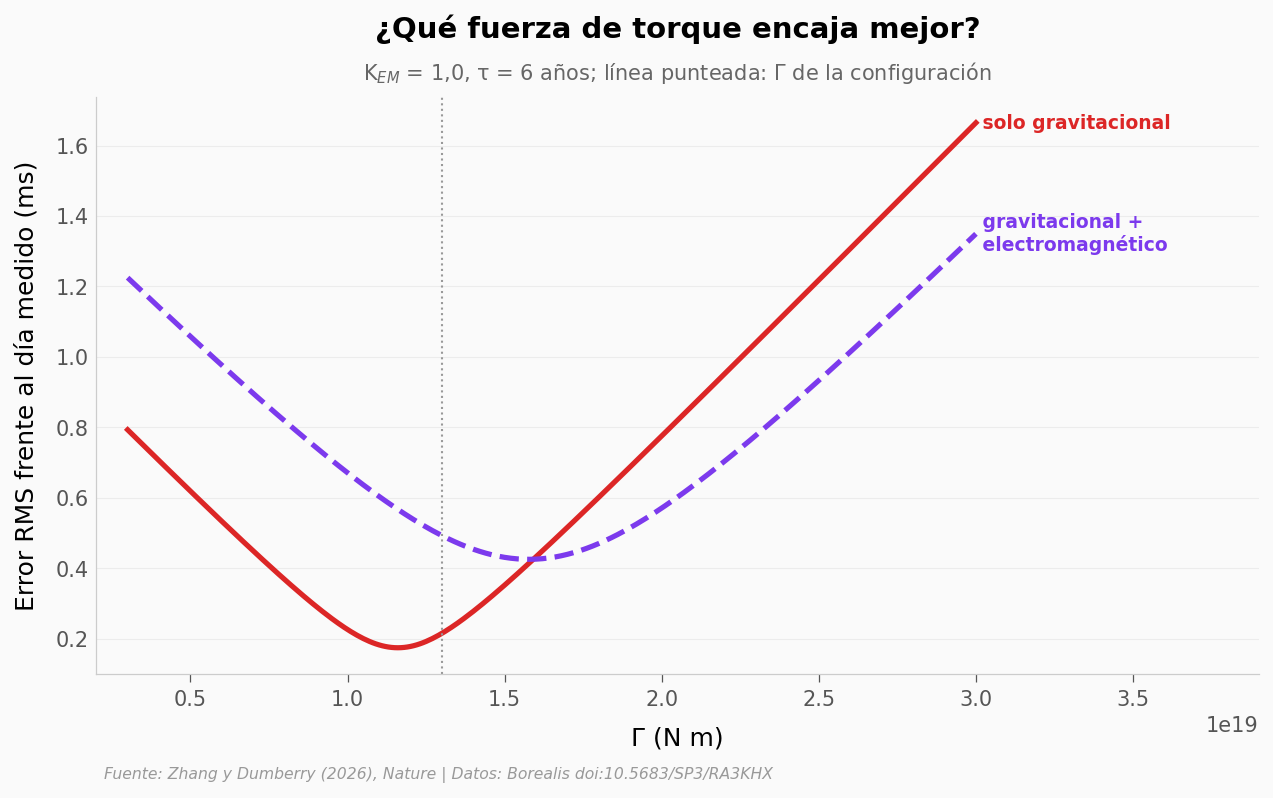

Solo gravitacional: mejor Γ = 1,16×10^19 N m (RMS 0,174 ms)
Gravitacional + EM: mejor Γ = 1,58×10^19 N m (RMS 0,425 ms)


In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Qué Γ minimiza el error si el torque gravitacional actúa solo, y si actúa junto al electromagnético?
# Ojo: el paper ajusta Γ, τ y K a la vez; aquí τ queda fijo en 6 años y K_EM en el valor de la configuración.
gammas = np.linspace(0.3e19, 3e19, 271)
obs = np.interp(t_grav, t_obs, lod_multi)
em_en_malla = np.interp(t_grav, t_cmb, lod_em)
rms_solo, rms_con_em = [], []
for gm in gammas:
    pred = lod_desde_torque(t_grav, gm * np.deg2rad(alf['alpha_grados'].values))
    rms_solo.append(np.sqrt(np.mean((pred - obs)**2)))
    suma = pred + em_en_malla
    rms_con_em.append(np.sqrt(np.mean((suma - suma.mean() - obs)**2)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(gammas, rms_solo, color=COLOR_ALERTA, lw=2.5)
ax.plot(gammas, rms_con_em, color=COLOR_EM, lw=2.5, ls='--')
ax.axvline(GAMMA_NM, color='#999999', lw=1, ls=':')
ax.text(gammas[-1], rms_solo[-1], ' solo gravitacional', color=COLOR_ALERTA, fontsize=9, fontweight='bold', va='center')
ax.text(gammas[-1], rms_con_em[-1], ' gravitacional +\n electromagnético', color=COLOR_EM, fontsize=9, fontweight='bold', va='center')
ax.set_xlim(0.2e19, 3.9e19)
ax.set_xlabel('Γ (N m)')
ax.set_ylabel('Error RMS frente al día medido (ms)')
ax.set_title('¿Qué fuerza de torque encaja mejor?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'K_EM = {K_EM}, τ = 6 años; línea punteada: Γ de la configuración'.replace('.', ',').replace('K_EM', 'K$_{EM}$'),
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/experimento_gamma.png', dpi=200, bbox_inches='tight')
plt.show()
pr(f'Solo gravitacional: mejor Γ = {gammas[np.argmin(rms_solo)]:.2e} N m (RMS {min(rms_solo):.3f} ms)')
pr(f'Gravitacional + EM: mejor Γ = {gammas[np.argmin(rms_con_em)]:.2e} N m (RMS {min(rms_con_em):.3f} ms)')

---

**Datos:** series de duración del día, torques en el borde núcleo-manto, desalineación del núcleo interno y muestras
del MCMC del repositorio de replicación del paper en Borealis (doi:10.5683/SP3/RA3KHX). Paper con licencia CC BY-NC-ND 4.0.

**Repositorio:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab/tree/main/papers/2026-09-23-torque-gravitacional-duracion-dia)

## Fuentes

**Paper**: [Gravitational torque drives multidecadal variations in length of day](https://doi.org/10.1038/s41586-026-10999-2)  
*Nature, 2026-09-23 · acceso abierto (CC BY-NC-ND 4.0)*

**Datos**: [Replication Data for: Gravitational torque drives multidecadal variations in length of day](https://doi.org/10.5683/SP3/RA3KHX)  
*Borealis, 2026-06-28 — series de duración del día, torques en el borde núcleo-manto, desalineación del núcleo interno y muestras del MCMC*

**Referencias citadas** (modelos de entrada que el notebook no abre): [Multidecadal variation of the Earth’s inner-core rotation](https://doi.org/10.1038/s41561-022-01112-z), [Transient core surface dynamics from ground and satellite geomagnetic data](https://doi.org/10.1093/gji/ggad039)

*19 afirmaciones del notebook verificadas contra estas fuentes*